# Mixed-Field Ising Model (MFIM) evolution using Matrix Product Operator (MPO) and Pauli chain Propagation

I've written some Julia module,
- `matrix_product_operator_functions.jl`, based on the MPO evolution method and the `ITensors.jl` (and `ITensorMPS.jl`) package for managing tensors,
- `pauli_propagation_functions.jl`, based on the paper “*Pauli Propagation: A Computational Framework for Simulating Quantum Systems*” and the associated package `PauliPropagation.jl`,
- `exact_functions.jl`, which simply calculates the “theoretical,” exact results of a propagation,
- `circuit.jl`, which allows you to initialize different types of circuits, including the MFIM, for the different methods we will need in this notebook.

These module allows me to handle propagation of an observable (in the Heisenberg picture) through a quantum circuit.

To test the different methods, we'll first focus on a simple, well-understood system to validate the method and develop our intuition before moving on to more complex circuits in future notebooks.

In [ ]:
# using Pkg; Pkg.add("LaTeXStrings"); Pkg.add("PauliPropagation"); Pkg.add("ITensors"); Pkg.add("ITensorMPS")

In [ ]:
using LaTeXStrings
using Plots
using LinearAlgebra

# --- Pauli Propagation ---
using PauliPropagation

#include("../src/pauli_propagation_functions.jl")
include("pauli_propagation_functions.jl")
import .pauli_propagation_functions as pp

# --- MPO ---
using ITensors, ITensorMPS

#include("../src/matrix_product_operator_functions.jl")
include("matrix_product_operator_functions.jl")
import .mpo_functions as mpo

# --- Exact method ---

#include("../src/exact_functions.jl")
include("exact_functions.jl")
import .exact_functions as ext

# --- Circuit ---
#include("../src/circuit.jl")
include("circuit.jl")
import .circuit as ct

# 1. Introduction

We consider a system of $n$ qubits arranged on a 1D chain. The quantum dynamics is generated by a circuit composed of **two-qubit gates U** applied in a **bricklayer pattern**.

<img src="https://github.com/TheoHUETQC/Quantum-ManyBody-Sim-Methods/blob/main/figures/brickwork_pattern_circuit.png?raw=1" width="600" alt="Block circuit">

We will discretize the time, and a layer is applied every $\tau=0.1$ time step.

In [ ]:
τ = 0.1

# Brick layer topology exemple
nqubits = 4
topology = bricklayertopology(nqubits; periodic=false)

3-element Vector{Tuple{Int64, Int64}}:
 (1, 2)
 (3, 4)
 (2, 3)

$j$ and $j+1$ are the topological tuples, so they are the nearest neighbors here.

So each layer consists of **nearest-neighbor gates** of the form:

$$
U_{j, j+1} = e^{-i \theta H_{j,j+1}}
$$

This type of evolution corresponds to a **Trotterized time evolution** under an **MFIM Hamiltonian**, $H$.

$$H = \sum_j ( X_j X_{j+1} + gX_j + hZ_j ) \quad \text{with} \quad g=1/2, h=1/2$$

where $X_j$ is the Pauli X operator acting on qubit $j$ (same for $Z_j$), and $\theta$ which is, in our case $\tau$, a fixed parameter (Trotter step).

For the Pauli propagation method, one can simply create a circuit that applies the correct layers :



In [ ]:
# Circuit exemple
g, h = 0.5, 0.5
steps = 50

MFIM_circuit_pp = ct.pp_TFIM_circuit(nqubits, steps; topology)
parameters = ones(countparameters(MFIM_circuit_pp)) * τ # all the \theta are τ

println("Gates in the circuit : ", length(parameters))

Gates in the circuit : 15


## 1.1 Trotter decomposition

Whereas, for the method using tensors, we will need to decompose our layers

$$H = \sum_j h_{j,j+1} \quad \text{where} \quad h_{j,j+1} = X_jX_{j+1} +\frac{g}{2}( X_j+X_{j+1})+\frac{h}{2}( Z_j+Z_{j+1})$$

$H$ can be decompose between $j_{odd}$ and $j_{even}$ so $H = H_{odd} + H_{even}$.

We take a small time step $\tau << 1$,
we can use the Baker-Campbell-Hausdorff formula to approximate :

$$U(\tau) = e^{-i \tau H} = e^{-i \tau (H_{odd} + H_{even})} = e^{-i \tau H_o} e^{-i \tau H_e} e^{-i \tau^2 [H_o,H_e]} = e^{-i \tau H_o} e^{-i \tau H_e} + O(\tau^2)$$
because of
$$e^{-i \tau^2 [H_o,H_e]} = \mathbb{I} - i \tau^2 [H_o, H_e] + O(\tau^4) $$

We have an error per time step $\tau$ of order $\tau^2$.

the $h_{j,j+1}$ for $j$ odd or even commute with each other, so

$$e^{-i \tau H_o} = e^{-i \tau \sum_{j_{odd}}h_{j,j+1}} = \prod_{j_{odd}} e^{-i \tau h_{j,j+1}} $$

same for $H_{even}$.

in conclusion we take

$$U^{TEBD2}(\tau) = e^{-iH\tau} \approx \prod_{j_{odd}}e^{-i\tau h_{j,j+1}/2} \prod_{j_{even}}e^{-i\tau h_{j,j+1}} \prod_{j_{odd}}e^{-i\tau h_{j,j+1}/2}$$

Wich have an error order of $\tau^3$.

Each term: $e^{-i\tau h_{j,j+1}}$ acts only on 2 spins.
Therefore, it can be represented as a 4-index tensor.
This is called a **TEBD gate**.

In [ ]:
# Circuit exemple

MFIM_circuit_mpo, sites = ct.mpo_compute_MFIM_circuit(nqubits, steps, τ, g, h)

println("Gates in the circuit : ", length(MFIM_circuit)*length(MFIM_circuit[1]))

---

## 1.1 Heisenberg picture

Instead of evolving a quantum state, we study the evolution of an observable $O$ in the Heisenberg picture:

$$
O(t) = U^\dagger O U
$$

In this notebook, we choose as initial observable a local Pauli operator:

$$
O = Z_i
$$

In [ ]:
# Observable exemple
Z_2_pauliString = PauliString(nqubits, :Z, 2) # IZI...I

PauliString(nqubits: 4, 1.0 * IZII)

Local observable implies max link dim need to be 1.

In [ ]:
ops = ["Id" for n in 1:nqubits]
ops[i] = "Z"
Z_i = MPO(sites, ops)
println("Max link dimension = ", maxlinkdim(Z_i))

---

## 1.2 Pauli propagation method

The key idea of **Pauli propagation** is to express the observable as a **sum of Pauli strings**:

$$
O = \sum_\alpha c_\alpha P_\alpha
$$

and to propagate each Pauli string through the circuit.

$P_\alpha$ a Pauli string is a tensor product of $\{I, X, Y, Z\}$, the Pauli matrices.

Exemple :
- for 5 qubits, it can be $X\otimes I \otimes Y\otimes I \otimes I$

Under conjugation by quantum gates, Pauli strings transform into linear combinations of other Pauli strings (and we call this type of object : `PauliSum`). This leads to a growth in the number of terms, which is controlled in practice using:

- **truncation of small coefficients** (if $c_\alpha < $ `min_abs_coeff` we truncate him)
- **limitation of the Pauli weight** (if $P_\alpha$ contains more than `max_weight` non identity Pauli matrices, we delete him)

This method is particularly efficient when the operator remains relatively **sparse in the Pauli basis**.

In [ ]:
# truncations exemple
max_weight = 3 # the max is nqubits
min_abs_coeff = 1e-4 # the min is 0.

0.0001

So propagating a Pauli string through a circuit transforms it into a Pauli sum.

We can use the `propagate` function from the package directly, but in the rest of this notebook we will use my `propagate_layerbylayer` function, which allows us to **calculate the evolution** of some physical quantity.

In [ ]:
# propagation exemple
Z2_t_pauli_sum = propagate(circuit, Z_2_pauliString, parameters; max_weight, min_abs_coeff)

PauliSum(nqubits: 4, 4 Pauli terms:
 -0.22985 * XZXI
 0.42074 * XYII
 0.77015 * IZII
 0.42074 * IYXI
)

We need to pay attention to the values of our truncations to avoid diverging from the exact solutions. We can verify whether our method is always implemented correctly by measuring the **norm of the observable**, which should be close to 1.

$$\sum_\alpha |c_\alpha|^2 = 1$$

In [ ]:
norm = pp.pauli_norm(Z2_t_pauli_sum)

1.0000000000000013

---

## 1.3 MPO and Max bond dimenstion ($\chi$)

With the MPO method, we use a cutoff to reduce computation time.
When the max link dimension reaches $2^N$, the max bond dimension, this means either that our system is far too entangled, or that our cutoff is not large enough.

In [ ]:
# Truncations
cutoff = 1e-8 # the min is 0.
maxdim = 500 # the max is 2^nqubits

The simpliest MPO possible, are the local operator, we can take identity.

In [ ]:
# MPO identity construction
IdMPO = MPO(sites, "Id")

println("Max link dimension = ", maxlinkdim(IdMPO))

Max link dimension = 1


 max link dimension $= 1 \implies \chi = 1$.
 
Let's test the robustness of our method by verifying a simple result.

If $\hat{O} = \mathbb{I}$ we have :

$$U^\dagger \mathbb{I} U = \mathbb{I} \qquad \forall U \text{ unitary}$$



In [ ]:
ψ0 = MPS(sites, ["Up" for _ in 1:nqubits]) # |↑↑..↑>

IdMPO_t, result_id = mpo.propagate_layerbylayer(MFIM_circuit, IdMPO; cutoff, maxdim, ψ0)

println("Max bond dimension = ", maxlinkdim(IdMPO_t))
println("\nIdentity distance = ", norm(IdMPO_t - IdMPO))

layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by mpo_functions.propagate_layerbylayer: 4.531149864196777 seconds
Max bond dimension = 1

Identity distance = 2.14197080046818e-14


This indeed gives the expected result:
$$U^{\dagger}\mathbb{I}U = \mathbb{I}$$

After applying the evolution, we arrive back at the identity, with a **numerical error** of the order of $10^{-14}$ for $100$ steps.

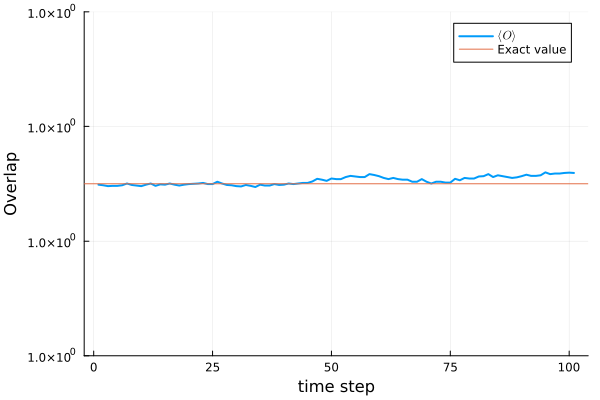

Average Overlap : 1.0000000000000016 ≈ 1


In [ ]:
overlap_values = result_id["overlap"]

dy = 1e-13
p = plot(overlap_values,
     xlabel="time step",
     ylabel="Overlap",
     label=L"\langle O \rangle",
     lw=2,
     ylims=(1-dy,1+dy))

hline!(p, [1], label="Exact value")
display(p)

println("Average Overlap : ", mean(overlap_values)," ≈ 1")

And the overlap $\langle \uparrow | \mathbb I | \uparrow \rangle \approx 1 \pm10^{-14}$.

---

# 2. Quantities and measurements

We just talked about overlap; let's define these quantities.

## 2.1 Overlap with the intial state $|0\rangle$

To test the method, we will examine the evolution of a physical quantity called the overlap, which is a trace between the operator and the density operator.

For the method that uses Pauli sums, it is easier to calculate the overlap with the zero state, since:

$$\langle A \rangle_{\psi(t)} = \langle \psi_0 | U^\dagger A U | \psi_0\rangle = \langle \psi_0 | A(t) | \psi_0\rangle = \langle \psi_0 | \sum_k c_k(t) P_k | \psi_0\rangle$$

$$\implies \langle A \rangle_{\psi(t)} = \sum_k c_k(t) \langle \psi_0 | P_k | \psi_0\rangle$$

We know :
- $\langle 0 | I | 0 \rangle = \langle 0 | 0 \rangle = 1$
- $\langle 0 | Z | 0 \rangle = \langle 0 | 0 \rangle = 1$
- $\langle 0 | X | 0 \rangle = \langle 0 | 1 \rangle = 0$
- $\langle 0 | Y | 0 \rangle = i \langle 0 | 1 \rangle = 0$

So if the initial state $| \psi_0 \rangle = |00\dots0\rangle$ :

$$\implies \langle A \rangle_{\psi(t)} = \sum_k c_k(t) \langle 00\dots0 | P_k | 00\dots0\rangle = \sum_{\alpha} c_\alpha(t)$$

where $\forall \alpha$, the pauli string $P_\alpha$ contains **only** the identity $I$ and the operator $Z$.

In [ ]:
function compute_overlapwithzero(pauli_sum::PauliSum)
  result = 0.0
  for (pauli_string, coeff) in pauli_sum
      string = pp.decode_pauli(pauli_string, pauli_sum.nqubits) # give the pauli string P_\alpha like "IXIZ"
      if !(contains(string, "X") || contains(string, "Y"))
          result += real(coeff)
      end
  end
  return result
end

compute_overlap (generic function with 1 method)

But in `PauliPropagation.jl` package we have a function `overlapwithzero()` which does exactly the same thing :

In [ ]:
overlap1 = compute_overlapwithzero(Z2_t_pauli_sum)
overlap2 = overlapwithzero(Z2_t_pauli_sum)

println("The two overlap are close : ", (overlap1 ≈ overlap2))

The two overlap are close : true


---

## 2.2 Correlation function

Features to add

---

# 3. Verification of the correct implementation of the method

We will compare our method by comparing the time-dependent overlap of a $\psi_0$ state ($\langle \psi_0 | \hat O(t) | \psi_0\rangle$) with the exact method.

By default, the wave functions in the modules take the state $|\psi_0 \rangle = | 0 \dots 0 \rangle$.

## 3.1 Initialisation

In [ ]:
function initialisation_TFIM(nqubits::Int64, steps::Int64, τ::Int64, i::Int64=2)
  # Pauli
  ## init circuit
  topology = bricklayertopology(nqubits; periodic=false)
  TFIM_circuit_pp = ct.pp_TFIM_circuit(nqubits, steps; topology)
  parameters = ones(countparameters(circuit)) * τ # parameters of all evolution gates take the same value dt

  ## init observable
  Z_i_pauliString = PauliString(nqubits, :Z, i) # IZI...I

  # MPO
  ## init circuit
  TFIM_circuit_mpo, sites = ct.mpo_compute_MFIM_circuit(nqubits, steps, τ/2, 0.0, 0.0) # with g, h = 0

  ## init observable
  ops = ["Id" for n in 1:nqubits]
  ops[i] = "Z"
  Z_i_mpo = MPO(sites, ops)
  return TFIM_circuit_pp, Z_i_pauliString, parameters, TFIM_circuit_mpo, sites, Z_i_mpo
end

initialisation (generic function with 3 methods)

In [ ]:
nqubits = 9
steps = 150
i = 2
τ = 0.1
truncation_tolerance = 1e-2

circuit_pp, Z_i_pauliString, parameters, circuit_mpo, sites, Z_i_mpo = initialisation_TFIM(nqubits, steps, τ, i)

Z_i_pauliString

Gates in the circuit : 1200


---

## 3.2 Propagation with the PauliPropagation method


In [ ]:
(max_weight, min_abs_coeff) = pp.find_truncations(truncation_tolerance, circuit_pp, Z_i_pauliString, steps)

In [ ]:
Zi_t_pauli_propagation, result_pp = pp.propagate_layerbylayer(circuit_pp, Z_i_pauliString, nlayers, parameters; max_weight, min_abs_coeff)

# we compute the matrix form of the pauli sum
Zi_t_pauli_propagation_matrix = pp.compute_matrix(Zi_t_pauli_propagation)

layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.006587982177734375 seconds


512×512 Matrix{ComplexF64}:
 0.577126+0.0im       0.0+0.0im  …        0.0+0.0im        0.0+0.0im
      0.0+0.0im  0.577126+0.0im           0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im           0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im           0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im           0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im  …        0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im           0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im           0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im           0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im           0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im  …        0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im           0.0+0.0im        0.0+0.0im
      0.0+0.0im       0.0+0.0im           0.0+0.0im        0.0+0.0im
         ⋮                       ⋱           ⋮       
      0.0+0.0im      

---

## 3.3 Propagation with the MPO method

We try to see if the method is well implemented so let's check without any truncation.

In [ ]:
(maxdim, cutoff) = pp.find_truncations(truncation_tolerance, circuit_mpo, Z_i_mpo)

256

In [ ]:
# propagation
Zi_t_mpo, result_mpo = mpo.propagate_layerbylayer(circuit_mpo, Z_i_mpo; cutoff, maxdim)

# Itensor -> matrix
Zi_t_matrix = mpo.compute_matrix(Zi_t_mpo, sites)

layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by mpo_functions.propagate_layerbylayer: 96.14078783988953 seconds
Contraction resulted in ITensor with 15 indices, which is greater
        than or equal to the ITensor order warning threshold 14.
        You can modify the threshold with macros like `@set_warn_order N`,
        `@reset_warn_order`, and `@disable_warn_order` or functions like
        `ITensors.set_warn_order(N::Int)`, `ITensors.reset_warn_order()`, and
        `ITensors.disable_warn_order()`.

Stacktrace:
  [1] _contract(A::ITensor, B::ITensor)
    @ ITensors ~/.julia/packages/ITensors/SDJ87/src/tensor_operations/tensor_algebra.jl:20
  [2] contract(A::ITensor, B::ITensor)
    @ ITensors ~/.julia/packages/ITensors/SDJ87/src/tensor_operations/tensor_algebra.jl

256×256 Matrix{ComplexF64}:
    0.0237935-2.80145e-15im  …   5.37612e-17+6.41648e-15im
 -1.06988e-15+5.14341e-15im      5.92087e-16+7.07529e-15im
   2.8559e-15-7.1e-15im          1.36823e-15+5.82323e-15im
  1.90062e-15+3.86399e-15im     -1.73724e-15+2.58889e-15im
  2.01676e-15+2.38705e-15im      4.15846e-15-3.22594e-15im
  1.86301e-15-1.42366e-15im  …   1.47855e-15-5.54106e-15im
 -2.22817e-15-5.63272e-15im      1.67882e-15-1.98695e-15im
  1.42986e-15+3.5118e-15im       6.18043e-15-1.50312e-15im
 -1.69266e-15+3.09383e-15im      6.68741e-15-1.28594e-15im
 -1.29344e-15+2.93362e-15im     -1.66961e-15+1.05054e-15im
 -1.89322e-15+1.71494e-15im  …   3.24942e-15+1.17356e-15im
 -3.76705e-15+1.91835e-15im      5.75248e-15-8.99781e-16im
  3.57303e-15-3.23639e-15im     -1.22805e-15-6.53591e-16im
             ⋮               ⋱              ⋮
  5.95317e-15-4.3847e-15im       4.30691e-15+1.75856e-15im
  3.67979e-15-3.87807e-15im  …  -1.42635e-16-8.41049e-16im
 -6.86252e-16-1.78785e-15im       3.7248e

In [ ]:
println("Max link dimension = ", maxlinkdim(Z_i_t))

Max link dimension = 256


Now, the operator isn't local.

---

## 3.4 Exact method

We can calculate the same circuit analytically and compare our results :

In [ ]:
Z_i = ext.get_Zi(nqubits, i)
circuit_exact = ct.exact_circuit_TFIM(nqubits, τ, steps)

Zi_t_exact, result_exact = ext.propagate_layerbylayer(circuit_exact, Z_i)

Zi_t_exact

layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 25.753151893615723 seconds


512×512 Matrix{ComplexF64}:
     0.577126+0.0im          …           0.0+0.0im
          0.0+0.0im             -3.42904e-16+0.0im
          0.0+0.0im                      0.0-3.67613e-16im
          0.0+5.34058e-16im              0.0+0.0im
          0.0+0.0im              5.32055e-16+0.0im
  6.68039e-16+0.0im          …           0.0+0.0im
          0.0-1.89109e-15im              0.0+0.0im
          0.0+0.0im                      0.0+1.72025e-15im
          0.0+0.0im                      0.0+1.58526e-16im
          0.0-1.56115e-15im              0.0+0.0im
 -4.85246e-17+0.0im          …           0.0+0.0im
          0.0+0.0im              4.85987e-16+0.0im
          0.0-2.00363e-15im              0.0+0.0im
             ⋮               ⋱  
 -1.88586e-16+0.0im          …           0.0+0.0im
          0.0+0.0im              9.95731e-16+0.0im
          0.0+0.0im                      0.0+6.61004e-16im
          0.0-2.19056e-16im              0.0+0.0im
          0.0-2.15674e-15im             

---

# 4. Result

## 4.1 Pauli

In [ ]:
is_close = isapprox(Zi_t_pauli_propagation_matrix, Zi_t_exact, rtol=1e-5)
println("Is the analytical calculation close to the Pauli propagation result?  ", is_close)

error_val = opnorm(Zi_t_pauli_propagation_matrix - Zi_t_exact)
println("with an error of :  ", error_val)

Is the analytical calculation close to the Pauli propagation result?  true
with an error of :  8.348426143624658e-14


We obtain the same $Z_i(t_{final})$, barring a numerical error of $10^{-14}$ with $150$ evolution steps.

Numerical error is calculate with the LinearAlgebra.jl function, `opnorm(A)`, corresponding to the spectral norm :
$$||A||_2 = \sqrt{\lambda_{max} (A^\dagger A) } = \sigma_{max}(A) $$

---

## 4.2 MPO


In [ ]:
is_close = isapprox(Zi_t_matrix, Zi_t_exact, rtol=1e-5)
println("Is the analytical calculation close to the Pauli propagation result?  ", is_close)

error_val = opnorm(Zi_t_matrix - Zi_t_exact)
println("with an error of :  ", error_val)

Is the analytical calculation close to the Pauli propagation result?  false
with an error of :  0.609621242204631


We obtain the same $Z_i(t_{final})$, barring a numerical error of $10^{-14}$ with $150$ evolution steps.

Numerical error is calculate with the LinearAlgebra.jl function, `opnorm(A)`, corresponding to the spectral norm :
$$||A||_2 = \sqrt{\lambda_{max} (A^\dagger A) } = \sigma_{max}(A) $$

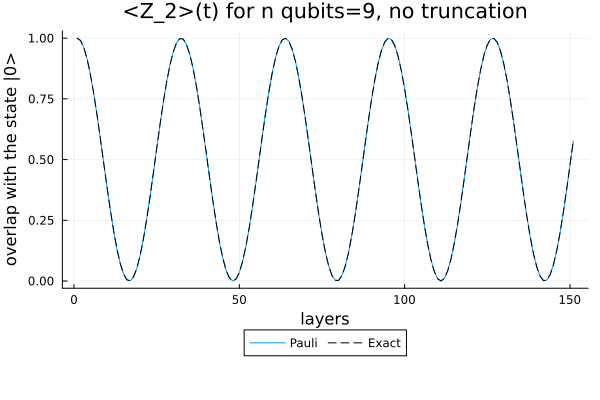

In [ ]:
overlap_pp = result_pp["overlap"]
overlap_mpo = result_mpo["overlap"]
overlap_exact = result_exact["overlap"]

p = plot(title="<Z_$i>(t) for n qubits=$nqubits, \n max weight=$max_weight, min abs coeff=$min_abs_coeff, \n Maxdim=$maxidim, Cutoff=$cutoff", xlabel="layers", ylabel="overlap with the state |0>")

plot!(p, overlap_pp, label="Pauli", line = (1, :solid))
plot!(p, overlap_mpo, label="MPO", line = (1, :solid))
plot!(p, overlap_exact, label="Exact", line = (1, :dash), color=:black)
plot!(legend=:outerbottom, legendcolumns=2)

display(p)

We obtain the same curve along the $150$ evolution steps.

In [ ]:
tolerance = 1e-2

In [ ]:
println("Z_$i (t_final) are close for the two methods (with a tolerance=$tolerance) ? ", isapprox(Zi_t_exact, Zi_t_pauli_propagation_matrix; rtol=tolerance))
println("the overlap's curve are close for the two methods (with a tolerance=$tolerance) ? ", isapprox(overlap_pp, overlap_exact; rtol=tolerance))

Z_2 (t_final) are close for the two methods (with a tolerance=0.01) ? true
the overlap's curve are close for the two methods (with a tolerance=0.01) ? true


We can see that for this type of circuit, our **result remains very close with weak truncations**, the result is close to the exact with a tolerance of $10^{-2}$.

This close result is because the **Pauli strings do not become complex in this type of circuit**, so truncation has very little effect, which prevents our results from diverging from the case without truncation.


In [ ]:
println("Exact methode take $(result_exact["time"]) sec")
println("Pauli methode take $(result_pp["time"]) sec")

Exact methode take 25.753151893615723 sec
Pauli methode take 0.006587982177734375 sec



The **Pauli propagation method works very well in this case** and **saves us significant computation time** compared to the exact method.

Which is no small advantage.

---

# Complexity

In [ ]:
steps, i = 150, 2
truncation_tolerance = 1e-2

0.01

--------- 4 ---------
--------- Exact method propagation ---------
layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 0.0054988861083984375 seconds
--------- Max weight TEST ---------
Max weight = 3, Min abs coeff = 1.0e-5
layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.0022590160369873047 seconds
Z_2 (t_final) are close for the two methods (with a tolerance=0.01) ? true
the overlap's curve are close for the two methods (with a tolerance=0.01) ? true
Optimal trincation find : (3, 1.0e-5)
---
--------- Min abs c

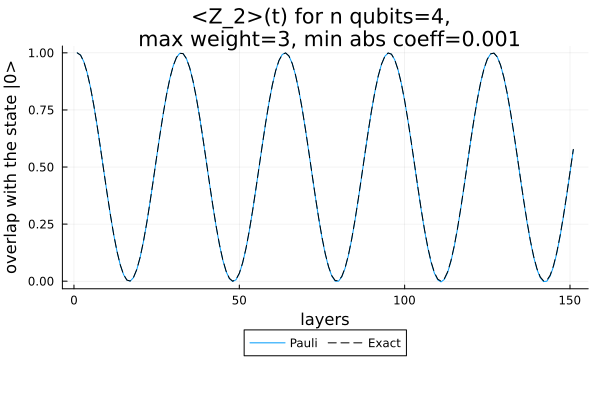

--------- 5 ---------
--------- Exact method propagation ---------
layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 0.0557100772857666 seconds
--------- Max weight TEST ---------
Max weight = 3, Min abs coeff = 1.0e-5
layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.0024640560150146484 seconds
Z_2 (t_final) are close for the two methods (with a tolerance=0.01) ? true
the overlap's curve are close for the two methods (with a tolerance=0.01) ? true
Optimal trincation find : (3, 1.0e-5)
---
--------- Min abs coef

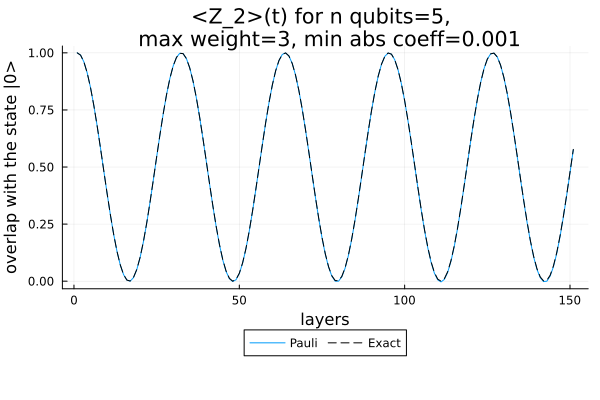

--------- 6 ---------
--------- Exact method propagation ---------
layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 0.130295991897583 seconds
--------- Max weight TEST ---------
Max weight = 3, Min abs coeff = 1.0e-5
layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.0012021064758300781 seconds
Z_2 (t_final) are close for the two methods (with a tolerance=0.01) ? true
the overlap's curve are close for the two methods (with a tolerance=0.01) ? true
Optimal trincation find : (3, 1.0e-5)
---
--------- Min abs coeff

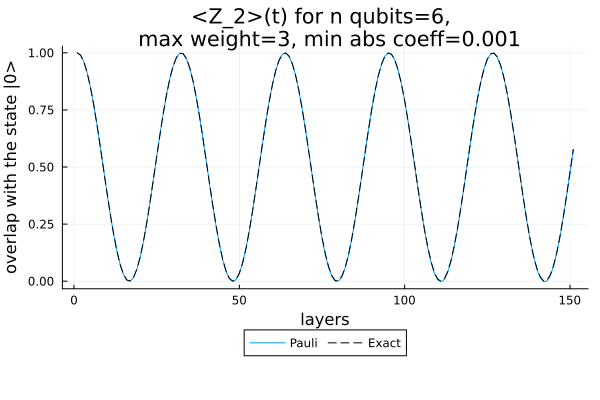

--------- 7 ---------
--------- Exact method propagation ---------
layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 0.5029439926147461 seconds
--------- Max weight TEST ---------
Max weight = 3, Min abs coeff = 1.0e-5
layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.002343893051147461 seconds
Z_2 (t_final) are close for the two methods (with a tolerance=0.01) ? true
the overlap's curve are close for the two methods (with a tolerance=0.01) ? true
Optimal trincation find : (3, 1.0e-5)
---
--------- Min abs coeff

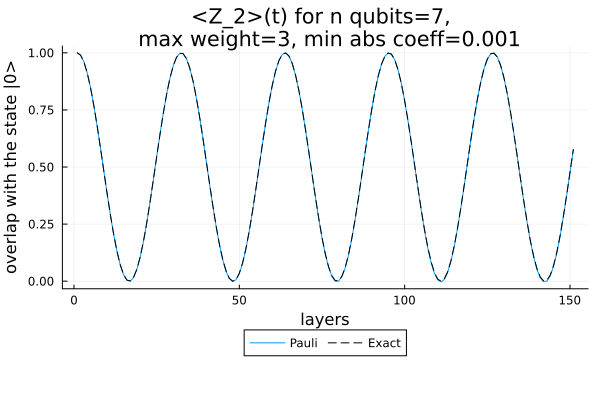

--------- 8 ---------
--------- Exact method propagation ---------
layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 4.098628044128418 seconds
--------- Max weight TEST ---------
Max weight = 3, Min abs coeff = 1.0e-5
layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.0037031173706054688 seconds
Z_2 (t_final) are close for the two methods (with a tolerance=0.01) ? true
the overlap's curve are close for the two methods (with a tolerance=0.01) ? true
Optimal trincation find : (3, 1.0e-5)
---
--------- Min abs coeff

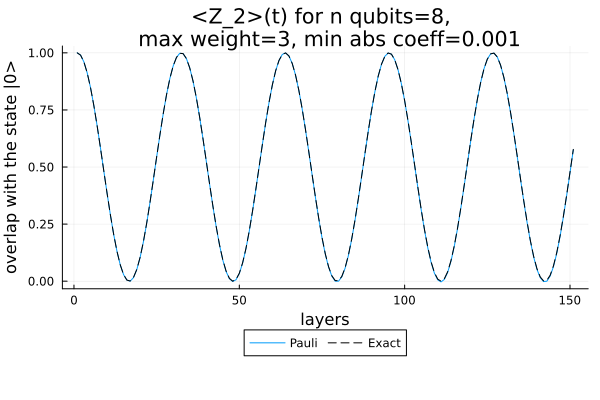

--------- 9 ---------
--------- Exact method propagation ---------
layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 22.32091784477234 seconds
--------- Max weight TEST ---------
Max weight = 3, Min abs coeff = 1.0e-5
layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.0029261112213134766 seconds
Z_2 (t_final) are close for the two methods (with a tolerance=0.01) ? true
the overlap's curve are close for the two methods (with a tolerance=0.01) ? true
Optimal trincation find : (3, 1.0e-5)
---
--------- Min abs coeff

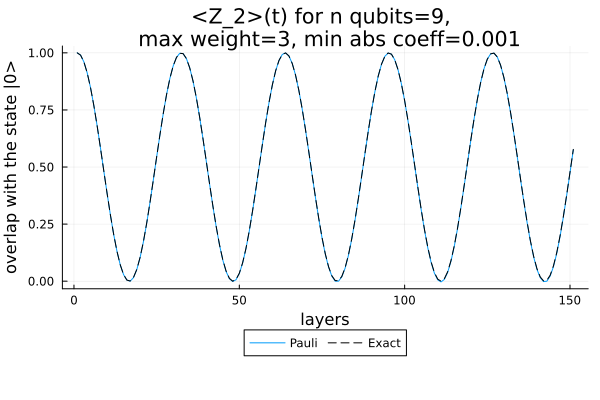

--------- 10 ---------
--------- Exact method propagation ---------
layer : 15 /150 complete
layer : 30 /150 complete
layer : 45 /150 complete
layer : 60 /150 complete
layer : 75 /150 complete
layer : 90 /150 complete
layer : 105 /150 complete
layer : 120 /150 complete
layer : 135 /150 complete
layer : 150 /150 complete
Time taken by ext.propagate_layerbylayer: 139.26446318626404 seconds
--------- Max weight TEST ---------
Max weight = 3, Min abs coeff = 1.0e-5
layer : 15/150 complete
layer : 30/150 complete
layer : 45/150 complete
layer : 60/150 complete
layer : 75/150 complete
layer : 90/150 complete
layer : 105/150 complete
layer : 120/150 complete
layer : 135/150 complete
layer : 150/150 complete
Time taken by pp.propagate_layerbylayer: 0.0055010318756103516 seconds
Z_2 (t_final) are close for the two methods (with a tolerance=0.01) ? true
the overlap's curve are close for the two methods (with a tolerance=0.01) ? true
Optimal trincation find : (3, 1.0e-5)
---
--------- Min abs coe

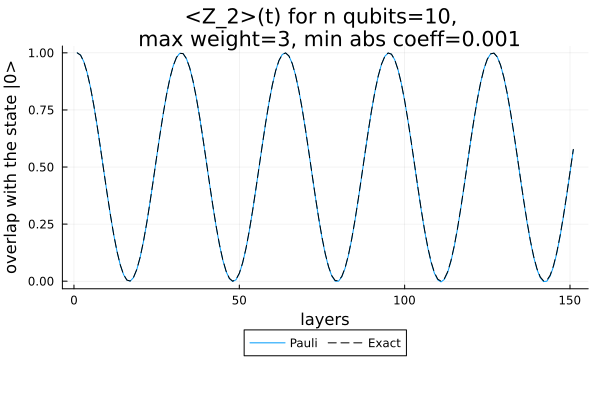

In [ ]:
times_exact, times_pp = Float64[], Float64[]

Ns = 4:10
for nqubits in Ns
  println("--------- $nqubits ---------")
  # Exact method
  println("--------- Exact method propagation ---------")
  Z_i = ext.get_Zi(nqubits, i)
  circuit_exact = ct.exact_circuit_TFIM(nqubits, dt, steps)
  Zi_t_exact, result_exact = ext.propagate_layerbylayer(circuit_exact, Z_i)
  overlap_exact = result_exact["overlap"]

  # Init methods
  circuit_pp, Z_i_pauliString, parameters, circuit_mpo, sites, Z_i_mpo = initialisation(nqubits, steps, i)

  # Pauli
  println("--------- method Pauli propagation ---------")
  ## test truncation
  (max_weight, min_abs_coeff) = pp.find_truncations(truncation_tolerance, circuit_pp, Z_i_pauliString, steps)

  ## optimal truncation application
  Zi_t_pauli_propagation, result_pp = pp.propagate_layerbylayer(circuit_pp, Z_i_pauliString, steps, parameters; max_weight, min_abs_coeff)
  overlap_pp = result_pp["overlap"]

  # MPO
  println("--------- MPO method propagation ---------")
  ## test truncation
  (maxdim, cutoff) = mpo.find_truncations(truncation_tolerance, circuit_mpo, Z_i_mpo)

  ## optimal truncation application
  Zi_t_mpo, result_mpo = mpo.propagate_layerbylayer(circuit_mpo, Z_i_mpo; cutoff, maxdim)
  overlap_mpo = result_mpo["overlap"]

  # plot to see if its good
  p = plot(title="<Z_$i>(t) for n qubits=$nqubits, \n max weight=$max_weight_optimal, min abs coeff=$min_abs_coeff_optimal", xlabel="layers", ylabel="overlap with the state |0>")
  plot!(p, overlap_pp, label="Pauli")
  plot!(p, overlap_mpo, label="MPO")
  plot!(p, overlap_exact, label="Exact", line = (1, :dash), color=:black)
  plot!(legend=:outerbottom, legendcolumns=2)
  display(p)

  # push the time of propagation to see complexity
  push!(times_exact, result_exact["time"])
  push!(times_pp, result_pp["time"])
  push!(times_mpo, result_mpo["time"])
end


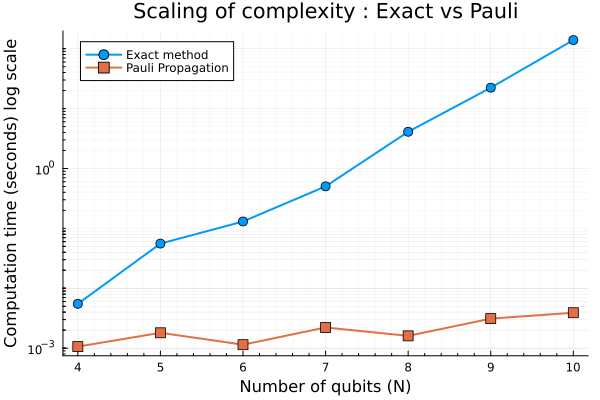

In [ ]:
plot(Ns, [times_exact, times_pp, times_mpo],
    label = ["Exact method" "Pauli Propagation" "MPO"],
    yaxis = :log10,                # Passage en échelle semi-log
    marker = [:circle :square :square],     # Ajout de points pour voir les mesures réelles
    markersize = 5,
    lw = 2,                        # Épaisseur de ligne
    xlabel = "Number of qubits (N)",
    ylabel = "Computation time (seconds) log scale",
    title = "Scaling of complexity : Exact vs Pauli",
    subtitle = "TFIM Circuit",
    legend = :topleft,
    grid = :both,
    minorgrid = true
)

---

## References

- https://arxiv.org/abs/2505.21606
- https://github.com/MSRudolph/PauliPropagation.jl
- [Julia documentation](https://docs.julialang.org/en/v1/)
- [ITensor documentation](https://docs.itensor.org/ITensors/stable/index.html)
- [Plots documentation](https://docs.juliaplots.org/stable/)
- [LaTeXStrings documentation](https://juliapackages.com/p/latexstrings)
- [LinearAlgebra documentation](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/)

- https://docs.juliaplots.org/dev/tutorial/
- https://www.phys.ens.psl.eu/~jacobsen/AMP21_Dubail.pdf
- https://tensornetwork.org/mps/algorithms/timeevo/tebd.html